In [8]:
# Install required libraries
!pip install psycopg2-binary sqlalchemy -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

print("All libraries loaded")

All libraries loaded


In [11]:
import io

# Paste your trades data directly - no database connection needed
csv_data = """trade_id,stock,sector,option_type,ratio,ratio_num,sell_strike,sell_price,sell_lots,buy_strike,buy_price,buy_lots,entry_date,entry_net_premium,exit_date,exit_net_premium,lot_size,pnl_inr,days_held,result
T001,Eicher Motors,Auto,CE,1:4,4.00,76000,33.00,2,8000,11.00,8,2026-04-08,-22.00,2026-04-08,-10.00,25,300,0,Win
T002,SBIN,Banking,CE,1:6,6.00,1140,6.70,2,1200,2.05,12,2026-04-08,-11.20,2026-04-08,-8.60,750,1950,0,Win
T003,Bharat Forge,Capital Goods,CE,1:4,4.00,2000,5.20,3,2120,1.80,12,2026-04-08,-6.00,2026-04-08,-3.60,500,1200,0,Win
T004,Bharti Airtel,Telecom,CE,1:8,8.00,2000,4.20,1,2100,1.60,8,2026-04-08,-8.60,2026-04-08,-6.10,500,1250,0,Win
T005,BDL,Defence,CE,1:4,4.00,1480,4.95,1,1600,1.65,4,2026-04-08,-1.65,2026-04-09,-0.40,1000,1250,1,Win
T006,HDFC Bank,Banking,CE,1:5,5.00,900,2.70,1,960,0.75,5,2026-04-08,-1.05,2026-04-09,0.25,550,-715,1,Loss
T007,HDFC Bank,Banking,CE,1:5,5.00,880,4.20,1,950,0.95,5,2026-04-08,0.45,2026-04-09,-0.55,550,550,1,Win
T008,HDFC Bank,Banking,CE,1:5,5.00,890,3.30,1,960,0.75,5,2026-04-08,-0.45,2026-04-09,-0.25,550,110,1,Win
T009,HUL,FMCG,CE,1:6,6.00,2260,10.75,1,2400,2.20,6,2026-04-08,-2.45,2026-04-09,-1.10,300,405,1,Win
T010,HUL,FMCG,CE,1:4,4.00,2300,6.30,5,2400,2.20,20,2026-04-08,-12.50,2026-04-13,5.30,300,-5340,5,Loss
T011,Maruti,Auto,CE,1:6,6.00,15000,32.90,2,16000,8.45,12,2026-04-08,-35.60,2026-04-09,-26.40,50,1310,1,Win
T012,SBIN,Banking,CE,1:4,4.00,1140,4.00,2,1200,1.70,8,2026-04-08,-5.60,2026-04-13,1.90,750,-3675,5,Loss
T013,SBIN,Banking,CE,1:5,5.00,1140,4.00,2,1200,1.20,10,2026-04-10,-4.00,2026-04-13,1.30,750,-3975,3,Loss
T014,United Spirits,Consumer Goods,CE,1:6,5.67,1400,3.00,3,1500,1.00,17,2026-04-08,-8.00,2026-04-17,3.80,500,-5900,9,Loss
T015,VBL,Consumer Goods,CE,1:4,4.00,470,1.50,4,500,0.55,16,2026-04-08,-2.80,2026-04-15,6.35,1000,-9150,7,Loss
T016,Shriram Finance,NBFC,CE,1:4,4.00,1130,5.80,1,1200,1.75,4,2026-04-08,-1.20,2026-04-08,-1.20,500,0,0,Win
T017,IRFC,PSU Finance,CE,1:4,4.00,110,0.60,3,120,0.18,12,2026-04-09,-0.36,2026-04-09,0.27,4000,-2520,0,Loss
T018,Bharat Forge,Capital Goods,CE,1:4,4.00,2000,4.70,2,2120,1.60,8,2026-04-09,-3.40,2026-04-10,-2.00,500,700,1,Win
T019,HDFC Bank,Banking,CE,1:4,4.00,850,7.10,2,900,2.20,8,2026-04-10,-3.40,2026-04-13,-0.40,550,1650,3,Win
T020,TCS,IT,CE,1:4,3.50,2680,12.40,6,2800,4.60,21,2026-04-10,-22.20,2026-04-15,8.10,150,-4545,5,Loss
T021,IRFC,PSU Finance,CE,1:5,5.00,110,0.78,3,120,0.21,15,2026-04-10,-0.81,2026-04-13,0.33,4000,-4560,3,Loss
T022,Reliance,Energy/Conglomerate,CE,1:4,4.00,1410,9.40,3,1500,2.60,12,2026-04-09,-2.80,2026-04-10,4.40,250,-1800,1,Loss
T023,Reliance,Energy/Conglomerate,CE,1:4,4.00,1420,8.20,2,1500,2.60,8,2026-04-09,-4.40,2026-04-10,2.25,250,-1663,1,Loss
T024,Reliance,Energy/Conglomerate,CE,1:5,5.00,1500,2.30,2,1600,0.90,10,2026-04-09,-4.40,2026-04-10,2.00,250,-1600,1,Loss
T025,BDL,Defence,CE,1:4,4.00,1500,7.00,2,1600,2.30,8,2026-04-10,-4.40,2026-04-13,2.80,1000,-7200,3,Loss
T026,BEL,Defence,CE,1:3,3.00,480,2.05,2,500,0.85,6,2026-04-10,-0.80,2026-04-17,-0.30,3500,1750,7,Win
T027,HDFC Bank,Banking,CE,1:5,5.00,890,2.15,6,950,0.65,30,2026-04-10,-6.60,2026-04-17,4.80,550,-6270,7,Loss
T028,HUL,FMCG,CE,1:4,4.00,2300,5.80,2,2400,1.95,8,2026-04-10,-4.00,2026-04-13,5.30,300,-2790,3,Loss
T029,NHPC,Power,CE,1:4,4.00,84,0.44,3,90,0.15,12,2026-04-10,-0.48,2026-04-13,-0.18,6000,1800,3,Win
T030,Sun Pharma,Pharma,CE,1:5,4.50,1750,7.40,4,1830,2.30,18,2026-04-10,-9.00,2026-04-13,1.65,350,-3728,3,Loss
T031,Voltas,Consumer Durables,CE,1:4,3.50,1500,5.10,4,1600,1.80,14,2026-04-13,-4.80,2026-04-13,-2.80,500,1000,0,Win
T032,HDFC Bank,Banking,CE,1:5,4.50,850,3.60,4,900,1.15,18,2026-04-13,-6.30,2026-04-16,-4.50,550,990,3,Win
T033,LT,Capital Goods,CE,1:9,9.00,4200,18.45,1,4500,3.05,9,2026-04-13,-9.00,2026-04-15,-18.00,50,450,2,Win
T034,Maruti,Auto,CE,1:4,4.00,14300,40.00,2,15000,13.00,8,2026-04-13,-24.00,2026-04-17,-24.00,50,0,4,Win
T035,Reliance,Energy/Conglomerate,CE,1:5,5.00,1420,3.45,3,1500,1.00,15,2026-04-13,-4.65,2026-04-15,-3.45,250,300,2,Win
T036,TCS,IT,CE,1:3,2.50,2600,14.35,4,2700,5.70,10,2026-04-13,-0.60,2026-04-15,-14.90,150,2145,2,Win
T037,TCS,IT,CE,1:9,9.00,2600,13.65,1,2800,2.60,9,2026-04-13,-9.75,2026-04-15,-14.30,150,684,2,Win
T038,United Spirits,Consumer Goods,CE,1:4,4.00,1340,4.15,1,1400,1.50,4,2026-04-13,-1.85,2026-04-16,0.00,500,925,3,Win
T039,United Spirits,Consumer Goods,CE,1:4,4.00,1340,4.60,1,1400,1.65,4,2026-04-15,-2.00,2026-04-16,0.00,500,1000,1,Win
T040,SBIN,Banking,CE,1:4,3.50,1160,2.25,2,1200,0.95,7,2026-04-15,-2.15,2026-04-20,-0.40,750,1313,5,Win
T041,SBIN,Banking,CE,1:4,4.00,1150,2.00,2,1200,0.90,8,2026-04-13,-3.20,2026-04-15,0.00,750,2400,2,Win
T042,Reliance,Energy/Conglomerate,CE,1:4,4.00,1390,8.20,5,1450,2.55,20,2026-04-15,-10.00,2026-04-15,13.50,250,-5875,0,Loss
T043,Reliance,Energy/Conglomerate,CE,1:4,4.00,1400,6.80,2,1460,2.10,8,2026-04-15,-3.20,2026-04-15,-0.80,250,600,0,Win
T044,Eicher Motors,Auto,CE,1:5,4.50,7600,41.00,2,8000,11.00,9,2026-04-15,-17.00,2026-04-16,5.60,25,555,1,Win
T045,Maruti,Auto,CE,1:4,3.50,14400,45.00,4,15000,16.10,14,2026-04-15,-45.40,2026-04-17,6.40,50,-2590,2,Loss
T046,NHPC,Power,CE,1:5,5.00,86,0.55,1,90,0.16,5,2026-04-15,0.07,2026-04-15,-0.46,6000,3180,0,Win
T047,NHPC,Power,CE,1:3,3.00,87,0.50,1,90,0.17,3,2026-04-15,0.09,2026-04-15,-0.65,6000,4440,0,Win
T048,TCS,IT,CE,1:4,3.50,2660,10.70,2,2760,4.20,7,2026-04-15,-8.00,2026-04-17,3.10,150,-1665,2,Loss
T049,TCS,IT,CE,1:4,3.50,2680,8.70,2,2780,3.55,7,2026-04-15,-10.45,2026-04-17,2.10,150,-1883,2,Loss
T050,TCS,IT,CE,1:4,4.00,2640,14.40,2,2760,4.65,8,2026-04-15,-8.50,2026-04-16,-8.60,150,15,1,Win
T051,TCS,IT,CE,1:4,4.00,2660,11.20,2,2780,3.80,8,2026-04-15,-8.00,2026-04-16,-8.10,150,15,1,Win
T052,Reliance,Energy/Conglomerate,CE,1:5,5.00,1450,3.00,2,1500,0.95,10,2026-04-15,-3.50,2026-04-17,0.30,250,950,2,Win
T053,SBIN,Banking,CE,1:4,3.50,1140,3.65,4,1180,1.35,14,2026-04-15,-4.30,2026-04-17,4.14,750,-6330,2,Loss
T054,Bajaj Finance,NBFC,PE,1:4,4.00,860,4.25,1,800,1.45,4,2026-04-16,-1.55,2026-04-16,-3.60,125,256,0,Win
T055,Bajaj Finance,NBFC,PE,1:4,4.00,840,4.00,1,780,1.25,4,2026-04-16,-1.00,2026-04-17,0.35,125,-169,1,Loss
T056,BDL,Defence,CE,1:5,5.00,1500,3.70,2,1600,1.25,10,2026-04-16,0.00,2026-04-16,1.50,1000,-1500,0,Loss
T057,Colpal,FMCG,CE,1:5,5.00,2100,6.50,1,2200,1.90,5,2026-04-16,-3.00,2026-04-16,-2.00,350,350,0,Win
T058,Voltas,Consumer Durables,CE,1:4,3.50,1540,5.00,4,1600,1.85,14,2026-04-16,-5.90,2026-04-20,-16.10,500,5100,4,Win
T059,Maruti,Auto,CE,1:5,4.50,14300,40.00,4,15000,12.00,18,2026-04-16,-56.00,2026-04-17,-56.00,50,0,1,Win
T060,TCS,IT,CE,1:4,3.50,2680,10.90,2,2780,4.00,7,2026-04-17,-7.80,2026-04-20,9.00,150,-2520,3,Loss
T061,Colpal,FMCG,CE,1:5,5.20,2300,4.90,5,2400,1.90,26,2026-04-17,-24.90,2026-04-20,18.50,350,-15190,3,Loss
T062,HUL,FMCG,CE,1:4,4.00,2300,8.70,1,2400,2.20,4,2026-04-17,-0.10,2026-04-17,-11.90,300,3540,0,Win
T063,HUL,FMCG,CE,1:4,3.50,2320,5.90,2,2400,2.20,7,2026-04-17,-3.60,2026-04-17,-16.00,300,3720,0,Win
T064,HUL,FMCG,CE,1:5,5.00,2400,3.60,3,2500,1.25,15,2026-04-17,-7.95,2026-04-17,3.60,300,-3465,0,Loss
T065,Maruti,Auto,CE,1:4,3.50,14500,51.50,6,15000,17.50,21,2026-04-17,-57.50,2026-04-20,57.50,50,-5750,3,Loss
T066,Angel One,NBFC,PE,1:7,7.00,270,0.90,2,235,0.23,14,2026-04-17,-1.42,2026-04-23,1.18,700,-1820,6,Loss
T067,Sun Pharma,Pharma,CE,1:4,4.00,1740,7.50,3,1800,2.40,12,2026-04-17,-6.30,2026-04-20,3.75,350,-3518,3,Loss
T068,SBIN,Banking,CE,1:4,3.50,1160,1.50,8,1200,0.60,28,2026-04-17,-4.80,2026-04-20,-1.60,750,2400,3,Win
T069,Wipro,IT,CE,1:8,8.00,230,0.17,1,250,0.06,8,2026-04-17,-0.31,2026-04-17,0.01,3000,-960,0,Loss
T070,Wipro,IT,CE,1:8,8.00,220,0.45,1,240,0.08,8,2026-04-17,-0.19,2026-04-23,0.19,3000,-1140,6,Loss
T071,Wipro,IT,PE,1:8,8.00,180,0.20,1,160,0.07,8,2026-04-17,-0.36,2026-04-22,0.34,3000,-2100,5,Loss
T072,SBIN,Banking,CE,1:4,4.00,1030,2.90,3,980,1.10,12,2026-04-20,-4.50,2026-04-21,5.25,750,-7313,1,Loss
T073,IRFC,PSU Finance,CE,1:5,5.00,110,0.72,2,118,0.18,10,2026-04-20,-0.34,2026-04-20,0.21,4000,-2200,0,Loss
T074,IRFC,PSU Finance,CE,1:5,5.00,112,0.45,1,120,0.12,5,2026-04-20,-0.15,2026-04-20,0.09,4000,-960,0,Loss
T075,GAIL,Energy,PE,1:8,8.00,145,0.30,2,130,0.12,16,2026-04-20,-1.32,2026-04-24,0.62,3000,-5820,4,Loss
T076,HDFC Bank,Banking,CE,1:8,8.00,845,2.00,2,900,0.45,16,2026-04-20,-3.20,2026-04-21,-3.60,550,220,1,Win
T077,HDFC Bank,Banking,PE,1:6,6.00,750,2.05,2,700,0.55,12,2026-04-20,-2.50,2026-04-21,0.10,550,-1430,1,Loss
T078,HUL,FMCG,CE,1:4,3.50,2340,5.43,6,2400,2.07,21,2026-04-20,-10.95,2026-04-21,8.50,300,-5835,1,Loss
T079,HUL,FMCG,PE,1:4,4.00,2080,2.30,2,2000,1.15,8,2026-04-20,-4.60,2026-04-21,2.40,300,-2100,1,Loss
T080,SBIN,Banking,PE,1:4,4.00,1000,4.50,1,1050,1.50,4,2026-04-20,-1.50,2026-04-21,0.15,750,-1238,1,Loss
T081,Reliance,Energy/Conglomerate,CE,1:5,4.50,1440,3.20,4,1500,1.05,18,2026-04-20,-6.10,2026-04-22,8.70,250,-3700,2,Loss
T082,Colpal,FMCG,CE,1:5,5.00,2300,4.90,4,2400,1.90,20,2026-04-20,-18.00,2026-04-21,17.00,350,-12250,1,Loss
T083,Trent,Retail,PE,1:4,4.00,4100,28.00,2,3800,8.00,8,2026-04-20,-8.00,2026-04-22,-18.00,175,1750,2,Win
T084,Sun Pharma,Pharma,CE,1:5,4.50,1740,3.30,2,1800,1.15,9,2026-04-21,-0.35,2026-04-21,0.55,350,-315,0,Loss
T085,Colpal,FMCG,PE,1:7,7.00,1900,2.50,2,1800,1.07,14,2026-04-21,-9.98,2026-04-24,7.10,350,-9380,3,Loss
T086,Bajaj Finance,NBFC,PE,1:4,4.00,870,2.50,4,820,1.03,16,2026-04-21,-6.48,2026-04-22,4.08,125,-444,1,Loss
T087,Havells,Consumer Durables,CE,1:3,2.50,1450,3.70,2,1500,1.80,5,2026-04-21,-1.60,2026-04-21,-1.60,500,0,0,Win
T088,HUL,FMCG,CE,1:5,5.00,2400,5.00,1,2500,1.40,5,2026-04-21,2.00,2026-04-21,-0.50,300,750,0,Win
T089,Mazagon Dock,Defence,PE,1:6,5.67,2400,5.50,3,2200,2.08,17,2026-04-21,-18.86,2026-04-22,14.75,250,1028,1,Win
T090,Nestle,FMCG,CE,1:3,2.50,1450,6.65,8,1500,2.70,20,2026-04-21,-0.80,2026-04-22,-26.00,50,1260,1,Win
T091,Nestle,FMCG,CE,1:4,3.50,1470,3.45,6,1500,3.20,21,2026-04-22,-46.50,2026-04-23,51.30,50,-2340,1,Loss
T092,Tata Elxsi,Auto,CE,1:4,3.50,4800,8.30,2,5000,3.80,7,2026-04-22,-9.80,2026-04-23,1.10,175,-1908,1,Loss
T093,IRFC,PSU Finance,CE,1:5,5.00,112,0.31,3,118,0.13,15,2026-04-22,-1.02,2026-04-23,-0.30,4000,2880,1,Win
T094,HCL Tech,IT,CE,1:3,3.00,1360,3.90,1,1400,1.65,3,2026-04-22,-1.05,2026-04-22,0.30,700,-927,0,Loss
T095,HCL Tech,IT,CE,1:4,3.50,1360,2.87,6,1400,1.25,21,2026-04-22,-9.03,2026-04-23,6.30,700,-10731,1,Loss
T096,Sun Pharma,Pharma,CE,1:5,4.50,1740,3.30,2,1800,1.15,9,2026-04-22,-0.35,2026-04-27,3.50,350,-1348,5,Loss
T097,Havells,Consumer Durables,CE,1:4,4.00,1340,3.00,4,1400,1.15,16,2026-04-23,-2.40,2026-04-23,2.00,500,-2200,0,Loss
T098,IREDA,PSU Finance,PE,1:5,5.00,130,0.32,2,120,0.12,10,2026-04-23,-0.56,2026-04-23,0.36,4000,-3680,0,Loss
T099,Trent,Retail,CE,1:4,3.50,4700,7.85,6,4900,3.65,21,2026-04-23,-29.85,2026-04-23,11.55,175,-7245,0,Loss
T100,VEDL,Metals,PE,1:5,5.00,690,1.15,2,640,0.45,10,2026-04-23,-1.60,2026-04-23,0.70,2000,-4600,0,Loss
T101,VEDL,Metals,CE,1:4,4.00,790,1.55,3,820,0.58,12,2026-04-23,-2.31,2026-04-24,2.25,2000,-9120,1,Loss
T102,VEDL,Metals,CE,1:4,4.00,785,1.25,1,800,0.50,4,2026-04-23,-0.75,2026-04-24,0.80,2000,-3100,1,Loss
T103,IRFC,PSU Finance,CE,1:5,5.00,113,0.25,6,118,0.14,30,2026-04-23,-2.70,2026-04-27,2.70,4000,-21600,4,Loss
T104,Sun Pharma,Pharma,CE,1:5,4.50,1740,2.90,6,1800,1.05,27,2026-04-23,-10.95,2026-04-24,14.25,350,-8853,1,Loss
T105,SBIN,Banking,PE,1:4,3.50,1030,1.00,2,1000,0.50,7,2026-04-23,-1.50,2026-04-24,0.50,750,750,1,Win
T106,Tata Elxsi,Auto,CE,1:4,3.50,4600,2.50,6,4800,2.00,21,2026-04-22,-29.50,2026-04-27,15.10,175,-7873,5,Loss
T107,Colpal,FMCG,CE,1:6,6.00,2000,2.00,4,1900,0.80,24,2026-04-24,-11.20,2026-04-27,3.68,350,-5208,3,Loss
T108,HCL Tech,IT,CE,1:4,3.33,1280,1.90,6,1320,0.90,20,2026-04-24,-6.60,2026-04-27,2.00,700,-5990,3,Loss
T109,Nestle,FMCG,CE,1:3,3.00,1460,3.90,2,1500,1.40,6,2026-04-24,-0.60,2026-04-27,1.20,50,-90,3,Loss
T110,Persistent,IT,CE,1:4,4.00,5300,10.25,2,5500,4.70,8,2026-04-24,-13.10,2026-04-24,10.20,150,-346,0,Loss
T111,BPCL,Energy,CE,1:5,5.00,325,0.50,1,340,0.20,5,2026-04-24,-0.50,2026-04-28,0.20,3000,-2100,4,Loss
T112,Colpal,FMCG,CE,1:5,5.00,2220,4.88,2,2300,1.35,10,2026-04-24,-3.76,2026-04-24,-3.26,350,175,0,Win
T113,Colpal,FMCG,CE,1:5,5.00,2240,3.55,2,2300,1.35,10,2026-04-24,-4.00,2026-04-24,-2.30,350,595,0,Win
T114,Dixon,Consumer Electronics,CE,1:4,3.50,11600,25.00,2,12000,10.00,7,2026-04-24,-20.00,2026-04-27,16.30,50,-1815,3,Loss
T115,Persistent,IT,CE,1:4,3.50,5000,15.05,4,5200,5.95,14,2026-04-24,-9.10,2026-04-27,19.20,150,-4245,3,Loss
T116,UltraCemco,Cement,CE,1:3,2.83,12700,37.50,6,13000,16.85,17,2026-04-24,-61.45,2026-04-27,-40.00,50,1073,3,Win
T117,Dixon,Consumer Electronics,CE,1:6,5.50,11700,20.00,4,12000,4.50,22,2026-04-27,-10.00,2026-04-28,3.40,50,-673,1,Loss"""

df = pd.read_csv(io.StringIO(csv_data))
df['entry_date'] = pd.to_datetime(df['entry_date'])
df['exit_date']  = pd.to_datetime(df['exit_date'])

print(f" Loaded {len(df)} trades")
print(f"Date range: {df['entry_date'].min().date()} → {df['exit_date'].max().date()}")
print(f"Stocks: {df['stock'].nunique()} | Sectors: {df['sector'].nunique()}")
df.head()

 Loaded 117 trades
Date range: 2026-04-08 → 2026-04-28
Stocks: 36 | Sectors: 19


,trade_id,stock,sector,option_type,ratio,ratio_num,sell_strike,sell_price,sell_lots,buy_strike,buy_price,buy_lots,entry_date,entry_net_premium,exit_date,exit_net_premium,lot_size,pnl_inr,days_held,result
0,T001,Eicher Motors,Auto,CE,1:4,4.0,76000,33.00,2,8000,11.00,8,2026-04-08,-22.00,2026-04-08,-10.0,25,300,0,Win
1,T002,SBIN,Banking,CE,1:6,6.0,1140,6.70,2,1200,2.05,12,2026-04-08,-11.20,2026-04-08,-8.6,750,1950,0,Win
2,T003,Bharat Forge,Capital Goods,CE,1:4,4.0,2000,5.20,3,2120,1.80,12,2026-04-08,-6.00,2026-04-08,-3.6,500,1200,0,Win
3,T004,Bharti Airtel,Telecom,CE,1:8,8.0,2000,4.20,1,2100,1.60,8,2026-04-08,-8.60,2026-04-08,-6.1,500,1250,0,Win
4,T005,BDL,Defence,CE,1:4,4.0,1480,4.95,1,1600,1.65,4,2026-04-08,-1.65,2026-04-09,-0.4,1000,1250,1,Win


In [12]:
wins   = df[df['result'] == 'Win']
losses = df[df['result'] == 'Loss']

total_pnl   = df['pnl_inr'].sum()
win_rate    = len(wins) / len(df) * 100
avg_win     = wins['pnl_inr'].mean()
avg_loss    = losses['pnl_inr'].mean()
rr_ratio    = abs(avg_win / avg_loss)
avg_hold    = df['days_held'].mean()
best_trade  = df.loc[df['pnl_inr'].idxmax()]
worst_trade = df.loc[df['pnl_inr'].idxmin()]

print("=" * 55)
print("   NSE OPTIONS INTELLIGENCE — APRIL 2026 SUMMARY")
print("=" * 55)
print(f"  Total Trades      : {len(df)}")
print(f"  Total P&L         : ₹{total_pnl:,.0f}")
print(f"  Win Rate          : {win_rate:.1f}%")
print(f"  Avg Win           : ₹{avg_win:,.0f}")
print(f"  Avg Loss          : ₹{avg_loss:,.0f}")
print(f"  Risk/Reward Ratio : {rr_ratio:.2f}x")
print(f"  Avg Hold Duration : {avg_hold:.1f} days")
print(f"  Best Trade        : {best_trade['stock']} ₹{best_trade['pnl_inr']:,.0f}")
print(f"  Worst Trade       : {worst_trade['stock']} ₹{worst_trade['pnl_inr']:,.0f}")
print(f"  Stocks Traded     : {df['stock'].nunique()}")
print(f"  Sectors Covered   : {df['sector'].nunique()}")
print("=" * 55)

   NSE OPTIONS INTELLIGENCE — APRIL 2026 SUMMARY
  Total Trades      : 117
  Total P&L         : ₹-219,849
  Win Rate          : 42.7%
  Avg Win           : ₹1,221
  Avg Loss          : ₹-4,192
  Risk/Reward Ratio : 0.29x
  Avg Hold Duration : 1.9 days
  Best Trade        : Voltas ₹5,100
  Worst Trade       : IRFC ₹-21,600
  Stocks Traded     : 36
  Sectors Covered   : 19


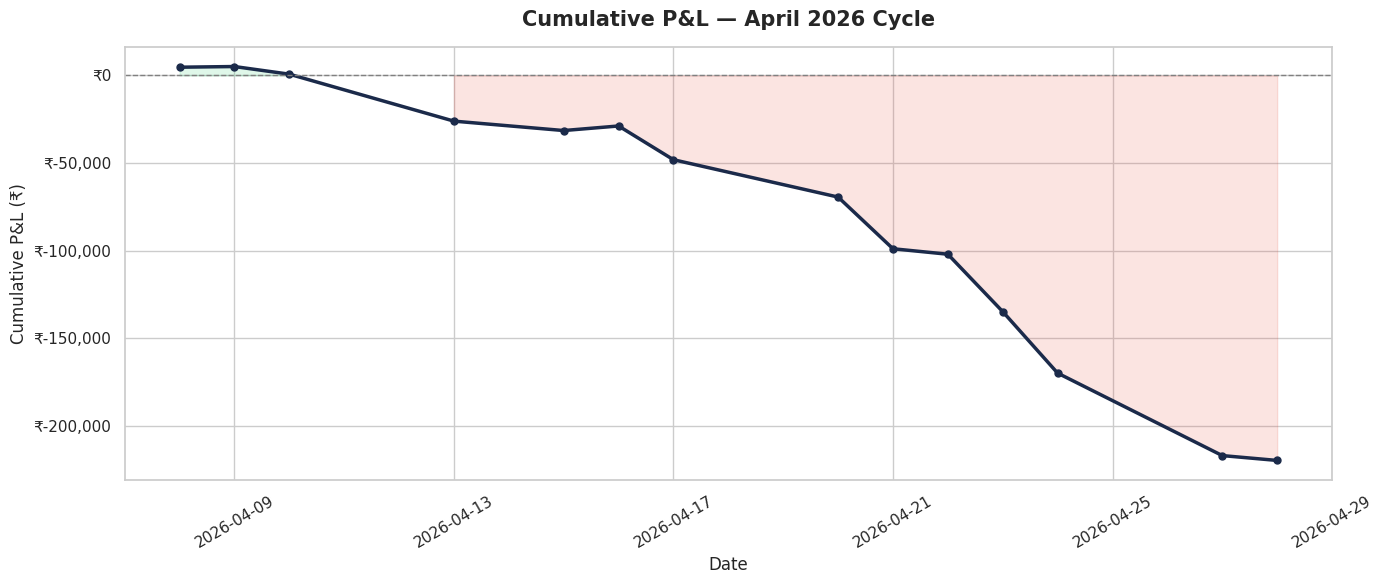

 Saved chart1_cumulative_pnl.png


In [13]:
daily = (df.groupby('exit_date')['pnl_inr']
           .sum()
           .reset_index()
           .sort_values('exit_date'))
daily['cumulative_pnl'] = daily['pnl_inr'].cumsum()

fig, ax = plt.subplots(figsize=(14, 6))
color = ['#2ecc71' if v >= 0 else '#e74c3c' for v in daily['cumulative_pnl']]
ax.fill_between(daily['exit_date'], daily['cumulative_pnl'], 0,
                where=(daily['cumulative_pnl'] >= 0), color='#2ecc71', alpha=0.15)
ax.fill_between(daily['exit_date'], daily['cumulative_pnl'], 0,
                where=(daily['cumulative_pnl'] < 0), color='#e74c3c', alpha=0.15)
ax.plot(daily['exit_date'], daily['cumulative_pnl'],
        color='#1B2A4A', linewidth=2.5, marker='o', markersize=5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_title('Cumulative P&L — April 2026 Cycle', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative P&L (₹)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('chart1_cumulative_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved chart1_cumulative_pnl.png")

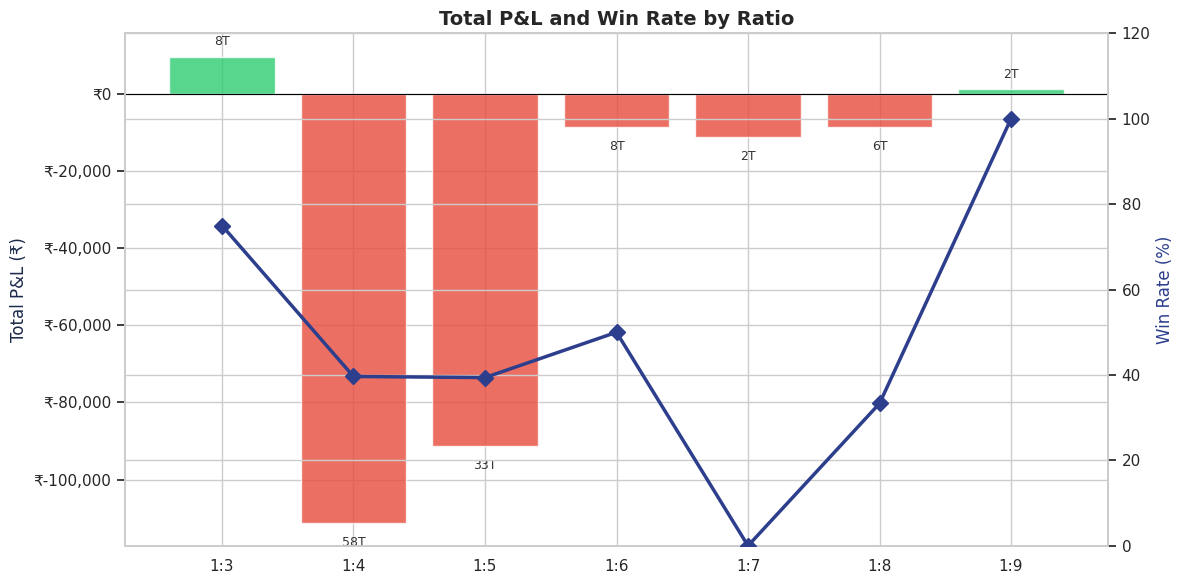

Saved chart2_ratio_analysis.png


In [14]:
ratio_stats = (df.groupby('ratio')
                 .agg(total=('pnl_inr','count'),
                      wins=('result', lambda x: (x=='Win').sum()),
                      total_pnl=('pnl_inr','sum'))
                 .reset_index())
ratio_stats['win_rate'] = ratio_stats['wins'] / ratio_stats['total'] * 100
ratio_stats = ratio_stats.sort_values('ratio')

fig, ax1 = plt.subplots(figsize=(12, 6))
bars = ax1.bar(ratio_stats['ratio'], ratio_stats['total_pnl'],
               color=['#2ecc71' if x > 0 else '#e74c3c' for x in ratio_stats['total_pnl']],
               alpha=0.8, zorder=2)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax1.set_ylabel('Total P&L (₹)', color='#1B2A4A')
ax1.set_title('Total P&L and Win Rate by Ratio', fontsize=14, fontweight='bold')

ax2 = ax1.twinx()
ax2.plot(ratio_stats['ratio'], ratio_stats['win_rate'],
         color='#2C3E8C', marker='D', linewidth=2.5, markersize=8, zorder=3)
ax2.set_ylabel('Win Rate (%)', color='#2C3E8C')
ax2.set_ylim(0, 120)

for i, row in ratio_stats.iterrows():
    ax1.text(row['ratio'], row['total_pnl'] + (3000 if row['total_pnl'] >= 0 else -6000),
             f"{row['total']}T", ha='center', fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('chart2_ratio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart2_ratio_analysis.png")

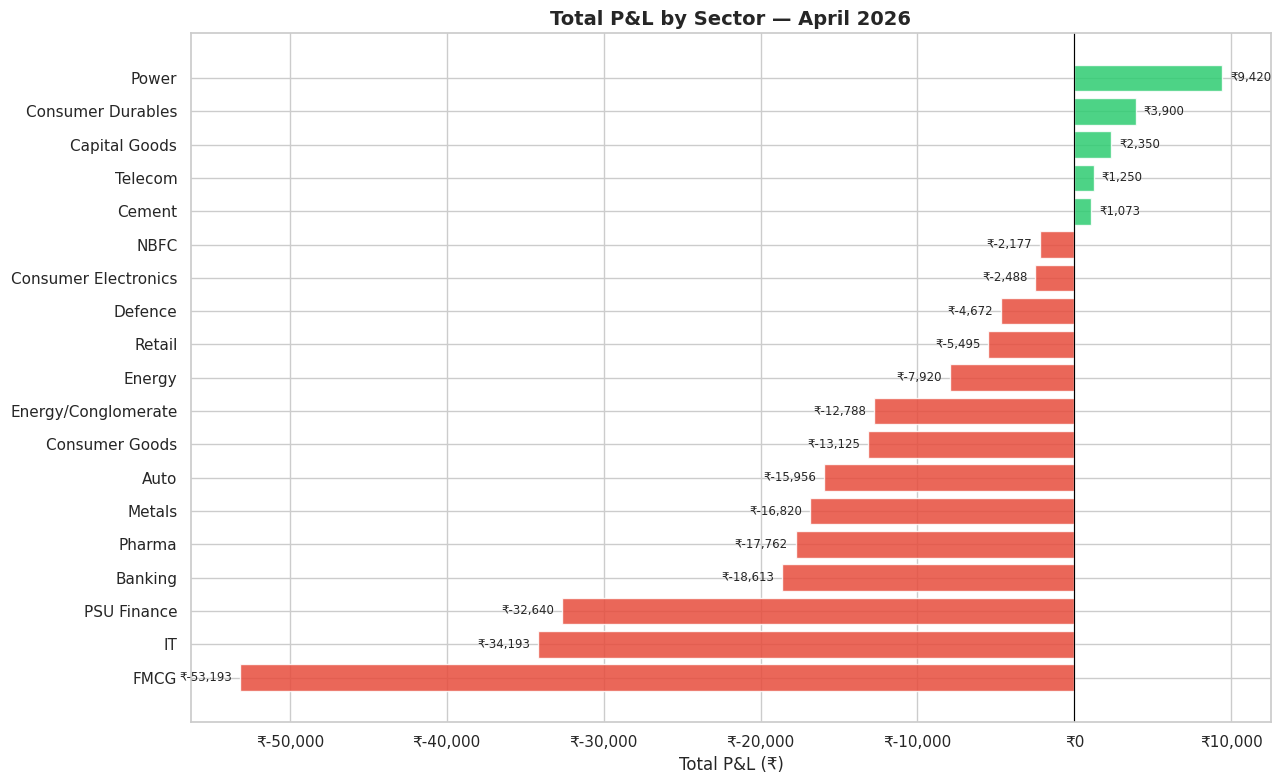

 Saved chart3_sector_pnl.png


In [15]:
sector_pnl = (df.groupby('sector')['pnl_inr']
                .sum()
                .sort_values()
                .reset_index())

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in sector_pnl['pnl_inr']]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(sector_pnl['sector'], sector_pnl['pnl_inr'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_title('Total P&L by Sector — April 2026', fontsize=14, fontweight='bold')
ax.set_xlabel('Total P&L (₹)')

for bar, val in zip(bars, sector_pnl['pnl_inr']):
    ax.text(val + (500 if val >= 0 else -500), bar.get_y() + bar.get_height()/2,
            f'₹{val:,.0f}', va='center', ha='left' if val >= 0 else 'right', fontsize=8.5)

plt.tight_layout()
plt.savefig('chart3_sector_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved chart3_sector_pnl.png")

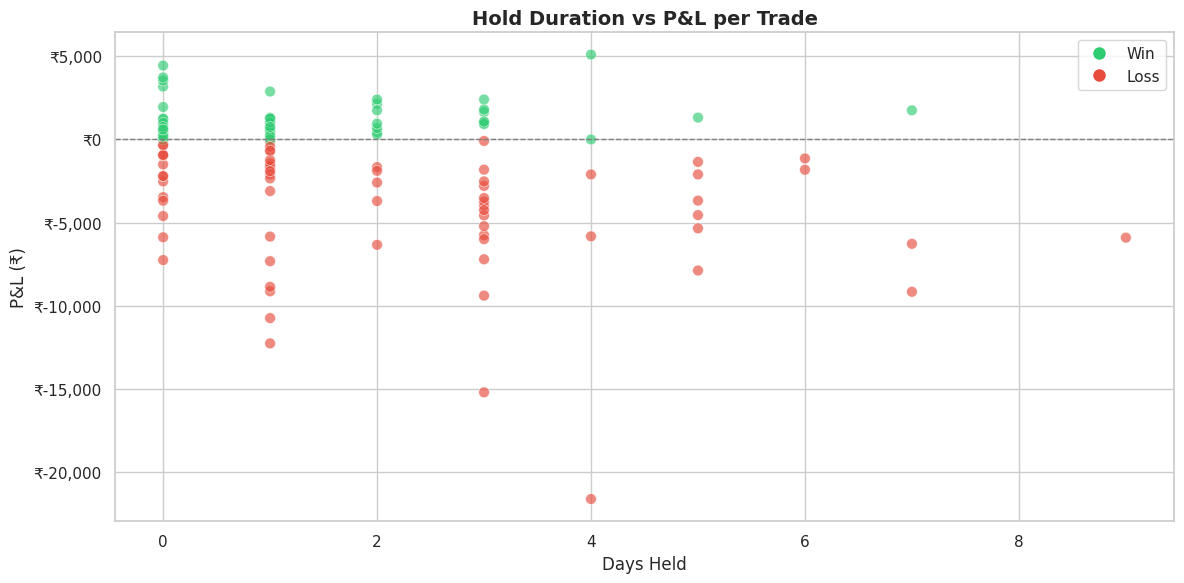

 Saved chart4_hold_vs_pnl.png


In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
scatter_colors = ['#2ecc71' if r == 'Win' else '#e74c3c' for r in df['result']]
ax.scatter(df['days_held'], df['pnl_inr'], c=scatter_colors, alpha=0.65, s=60, edgecolors='white', linewidth=0.5)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Win'),
                   Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Loss')]
ax.legend(handles=legend_elements)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_title('Hold Duration vs P&L per Trade', fontsize=14, fontweight='bold')
ax.set_xlabel('Days Held')
ax.set_ylabel('P&L (₹)')

plt.tight_layout()
plt.savefig('chart4_hold_vs_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved chart4_hold_vs_pnl.png")

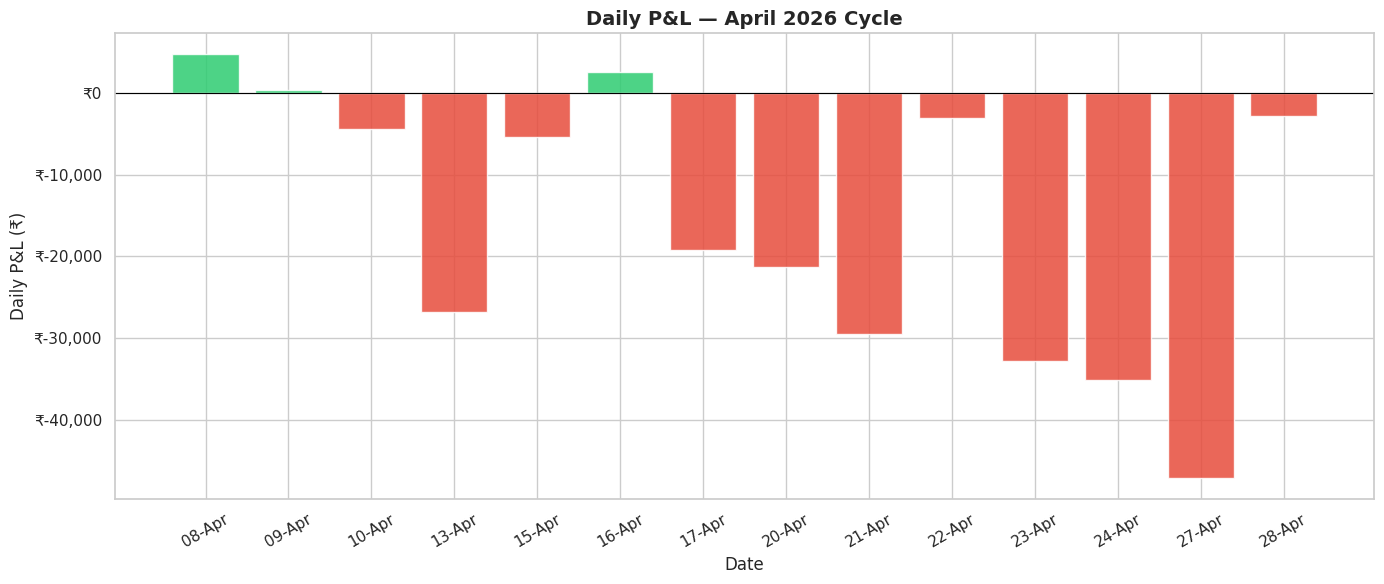

Saved chart5_daily_pnl.png


In [17]:
daily['color'] = daily['pnl_inr'].apply(lambda x: '#2ecc71' if x >= 0 else '#e74c3c')

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(daily['exit_date'].dt.strftime('%d-%b'), daily['pnl_inr'],
       color=daily['color'], alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.set_title('Daily P&L — April 2026 Cycle', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Daily P&L (₹)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.savefig('chart5_daily_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved chart5_daily_pnl.png")

In [18]:
df_ml = df.copy()

# Encode categorical features as numbers
df_ml['is_pe']          = (df_ml['option_type'] == 'PE').astype(int)
df_ml['target']         = (df_ml['result'] == 'Win').astype(int)

sector_map = {s: i for i, s in enumerate(df_ml['sector'].unique())}
df_ml['sector_encoded'] = df_ml['sector'].map(sector_map)

# Hold duration bucket
df_ml['hold_bucket'] = pd.cut(df_ml['days_held'],
                               bins=[-1, 0, 2, 5, 100],
                               labels=[0, 1, 2, 3]).astype(int)

features = ['ratio_num', 'is_pe', 'sector_encoded',
            'hold_bucket', 'entry_net_premium', 'sell_lots', 'buy_lots']

X = df_ml[features]
y = df_ml['target']

print(" Features ready")
print(f"Feature matrix shape: {X.shape}")
print(f"\nWin/Loss split: {y.value_counts().to_dict()}")
X.head()

 Features ready
Feature matrix shape: (117, 7)

Win/Loss split: {0: 67, 1: 50}


,ratio_num,is_pe,sector_encoded,hold_bucket,entry_net_premium,sell_lots,buy_lots
0,4.0,0,0,0,-22.00,2,8
1,6.0,0,1,0,-11.20,2,12
2,4.0,0,2,0,-6.00,3,12
3,8.0,0,3,0,-8.60,1,8
4,4.0,0,4,1,-1.65,1,4


In [19]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

# Scale for logistic regression
scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test_sc))

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print(f"Logistic Regression Accuracy : {lr_acc*100:.1f}%")
print(f"Random Forest Accuracy       : {rf_acc*100:.1f}%")
print(f"\nCross-val score (RF, 5-fold) : "
      f"{cross_val_score(rf, X, y, cv=5).mean()*100:.1f}%")

print("\n--- Classification Report (Random Forest) ---")
print(classification_report(y_test, rf.predict(X_test),
                             target_names=['Loss','Win']))

Logistic Regression Accuracy : 56.7%
Random Forest Accuracy       : 66.7%

Cross-val score (RF, 5-fold) : 59.1%

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

        Loss       0.73      0.65      0.69        17
         Win       0.60      0.69      0.64        13

    accuracy                           0.67        30
   macro avg       0.67      0.67      0.67        30
weighted avg       0.68      0.67      0.67        30



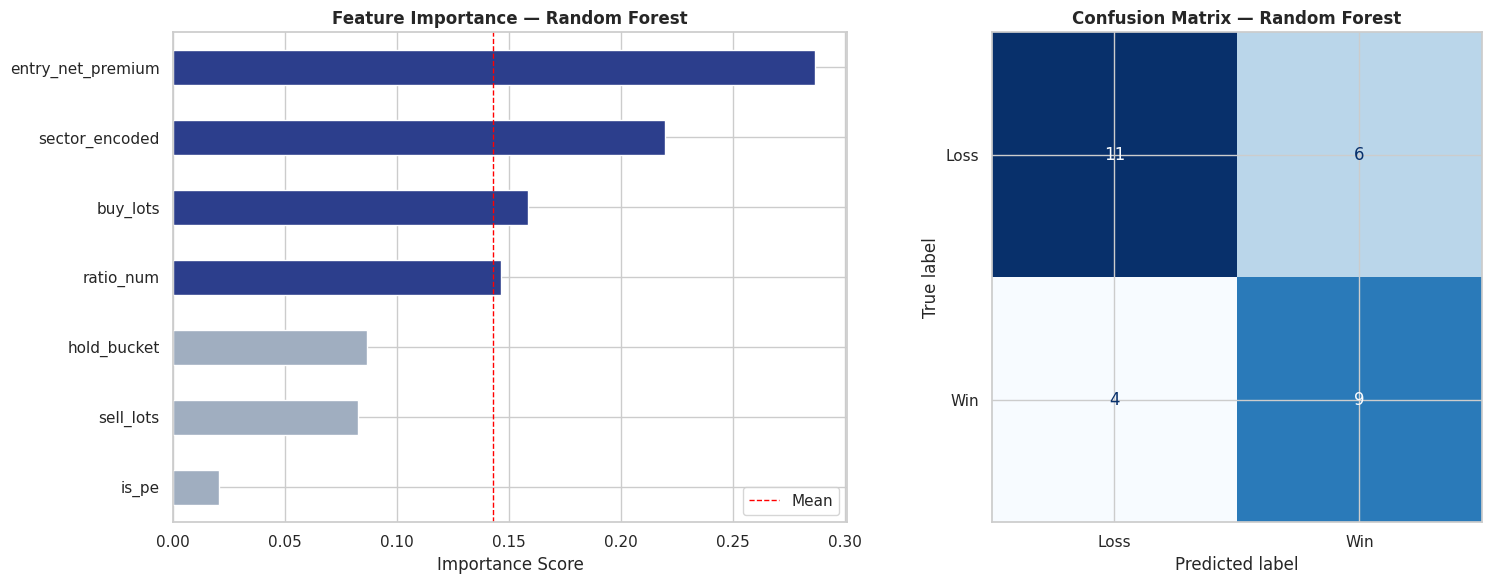

 Saved chart6_ml_results.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
colors_fi = ['#2C3E8C' if v > importances.mean() else '#A0AEC0' for v in importances]
importances.plot(kind='barh', ax=axes[0], color=colors_fi)
axes[0].set_title('Feature Importance — Random Forest', fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(importances.mean(), color='red', linestyle='--', linewidth=1, label='Mean')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(y_test, rf.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Loss','Win'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Confusion Matrix — Random Forest', fontweight='bold')

plt.tight_layout()
plt.savefig('chart6_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved chart6_ml_results.png")

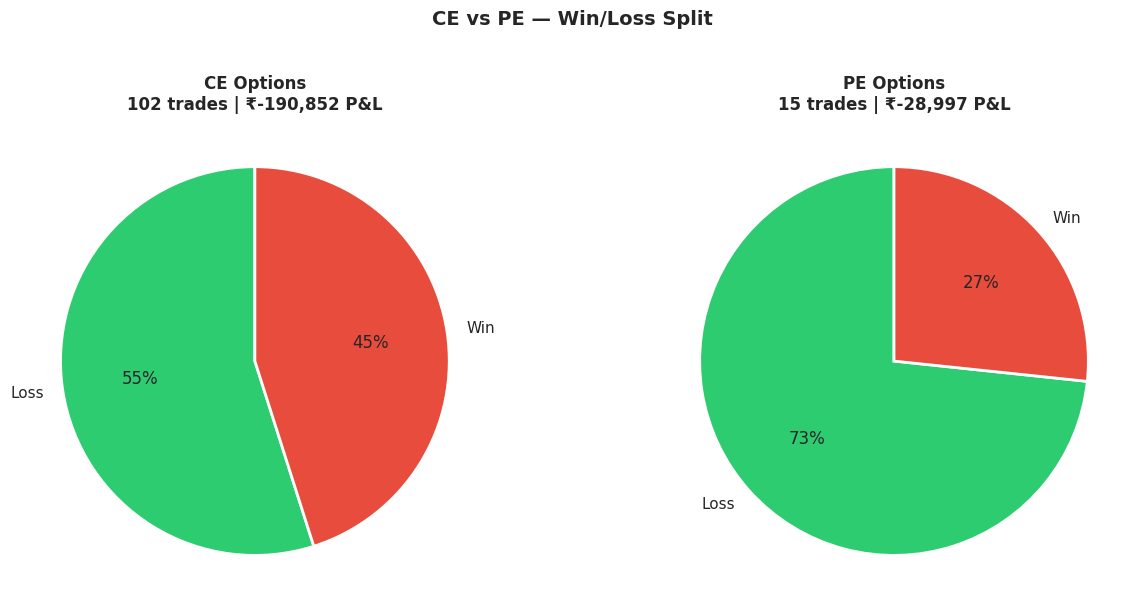

 Saved chart7_ce_vs_pe.png


In [21]:
ce_pe = (df.groupby(['option_type', 'result'])
           .size()
           .unstack(fill_value=0)
           .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for idx, ot in enumerate(['CE', 'PE']):
    sub = df[df['option_type'] == ot]
    wr  = (sub['result'] == 'Win').mean() * 100
    pnl = sub['pnl_inr'].sum()
    counts = sub['result'].value_counts()
    axes[idx].pie(counts, labels=counts.index,
                  colors=['#2ecc71','#e74c3c'],
                  autopct='%1.0f%%', startangle=90,
                  wedgeprops={'edgecolor':'white','linewidth':2})
    axes[idx].set_title(f'{ot} Options\n{len(sub)} trades | ₹{pnl:,.0f} P&L',
                        fontweight='bold')

plt.suptitle('CE vs PE — Win/Loss Split', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart7_ce_vs_pe.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved chart7_ce_vs_pe.png")

In [22]:
df.to_csv('trades_april2026.csv', index=False)
print("Saved trades_april2026.csv")
print(f"Columns: {list(df.columns)}")

Saved trades_april2026.csv
Columns: ['trade_id', 'stock', 'sector', 'option_type', 'ratio', 'ratio_num', 'sell_strike', 'sell_price', 'sell_lots', 'buy_strike', 'buy_price', 'buy_lots', 'entry_date', 'entry_net_premium', 'exit_date', 'exit_net_premium', 'lot_size', 'pnl_inr', 'days_held', 'result']


In [23]:
from google.colab import files

for f in ['trades_april2026.csv',
          'chart1_cumulative_pnl.png',
          'chart2_ratio_analysis.png',
          'chart3_sector_pnl.png',
          'chart4_hold_vs_pnl.png',
          'chart5_daily_pnl.png',
          'chart6_ml_results.png',
          'chart7_ce_vs_pe.png']:
    files.download(f)
    print(f"Downloaded {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded trades_april2026.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded chart6_ml_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded chart7_ce_vs_pe.png
